# Quoridor AI — 9×9 Training (N=4)

**Group 501** | Colman College | DL Final Project

Full-size 4-player Quoridor (9×9, 5 walls/player) trained via sequential self-play.
All hyperparameters are read from `configs/config_9x9.json`.

**Note:** Train the N=2 model first (`train_9x9_n2.ipynb`) to validate the
pipeline before committing to the longer N=4 run.

**Two ways to run:**

**A. Interactively** (this notebook) — run cells top to bottom.
If the kernel disconnects, re-run from Section 1; `resume=True` picks up from the last checkpoint.

**B. Detached / headless** (survives SSH or browser disconnect) — run from a terminal:
```bash
NOTEBOOK=notebooks/train_9x9_n4.ipynb scripts/run_notebook.sh   # this notebook (N=4)
tail -f runs/train_9x9_n4/notebook.log                          # monitor
```
This executes the whole notebook via `nohup jupyter nbconvert --execute`, so it
keeps running at the OS level even if you close the browser or drop SSH.

## Security & Data Warning

**DO NOT commit or upload:**
- API keys, authentication tokens, or passwords
- Model checkpoints containing sensitive training data
- File paths with personal/org information

**Best practices:**
- Store checkpoints in private cloud storage or local machine
- Use `.gitignore` to exclude model files: `*.pth`, `*.ckpt`, `configs/*.local`
- For Colab: download checkpoints before session ends or save to private Drive

## Expected Output & Monitoring

**During training, expect:**
- `[GPU] 500 batches processed...` every ~500 batches (progress indicator)
- Game summaries: `winner=Player X, walls: [8, 9, 8, 10]` (one per iteration)
- Win statistics at iteration end: `{0: 45, 1: 35, 2: 10, None: 10}` (draws)
- Loss/accuracy metrics from model training

**Runtime expectations (9x9, N=2, T4 GPU):**
- ~8 min per self-play iteration (200 games with batched inference)
- ~2 min model training per iteration
- Full training (100 iterations): ~16-20 hours

**Troubleshooting:**
- **OOM error**: Reduce `inference_batch_size` in config or `num_workers`
- **Slow training**: Ensure GPU is active (check `!nvidia-smi`)
- **Hung process**: Cells timeout after 90 min; re-run will resume with `resume=True`

---
## 1. Environment Setup
Run once per Colab session.

In [1]:
# 1.1 — Install dependencies and setup repo
import os, sys

# Find repo root (works from any starting directory)
REPO_DIR = None
for candidate in [
    os.getcwd(),                             # already in repo root
    os.path.join(os.getcwd(), "dl-quoridor"),  # Jupyter workspace root
    os.path.dirname(os.getcwd()),            # running from notebooks/
]:
    if os.path.exists(os.path.join(candidate, ".git")):
        REPO_DIR = candidate
        break

assert REPO_DIR is not None, (
    "Could not find dl-quoridor repo. "
    "Make sure the notebook is inside the repo or one level above it."
)

os.chdir(REPO_DIR)
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

# The branch this run's config and training code live on. `git checkout .`
# below discards local edits first, so a stale BRANCH silently runs old code —
# that is how the v4/v5 runs ended up without any of their intended fixes.
BRANCH = "feat/9x9-v8"
!cd {REPO_DIR} && git checkout . && git checkout {BRANCH} && git pull

print(f"Repo: {REPO_DIR}")

# Install requirements (--ignore-installed handles system-managed packages)
!pip install -r requirements.txt -q --ignore-installed
print("Dependencies installed.")

Updated 0 paths from the index
Already on 'feat/9x9-v8'
Your branch is up to date with 'origin/feat/9x9-v8'.


Already up to date.


Repo: /tf/dl-quoridor


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
notebook 7.5.4 requires jupyterlab<4.6,>=4.5.5, but you have jupyterlab 4.6.2 which is incompatible.

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python3 -m pip install --upgrade pip


Dependencies installed.


In [2]:
# 1.2 — Detect hardware and auto-tune parallel settings
import torch, multiprocessing, psutil

print(f"torch {torch.__version__}")
CPU_CORES = multiprocessing.cpu_count()
RAM_GB = psutil.virtual_memory().total / 1e9
print(f"CPU cores: {CPU_CORES}")
print(f"RAM: {RAM_GB:.1f} GB")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("No GPU detected — training will run on CPU (slow for 9x9 N=4).")

# Worker and batch counts come from configs/config_9x9.json (read in 2.1), not
# from this cell. Measured 9x9 N=4: 64 workers = 5.5s/game, 128 = 5.6s/game, so
# there is no gain past 64.
# NOTE: running N=2 and N=4 concurrently is fine. Measured on the v3 runs,
#       which overlapped for ~9.5h: n2 self-play averaged 642s/iter while n4
#       was also running vs 894s/iter alone, so sharing the GPU cost nothing
#       measurable at 64 workers each. Both kernel deaths in that run happened
#       while n2 was running by itself.

torch 2.13.0+cu130
CPU cores: 256
RAM: 1623.1 GB
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition
VRAM: 21.6 GB


In [3]:
# 1.3 — Set run directory for checkpoints
# v6 = first run on tensor spec v2 (distance planes / 2*board_size) with the
# wall-mask curriculum, keeping v5's ply-counted discount. A fresh dir on
# purpose: v5's weights are v1-calibrated and the curriculum starts at iter 0.
RUN_DIR = os.path.join(REPO_DIR, "runs", "n4_9x9_v8")
os.makedirs(RUN_DIR, exist_ok=True)
print(f"Run dir: {RUN_DIR}")

Run dir: /tf/dl-quoridor/runs/n4_9x9_v8


---
## 2. Configuration

In [4]:
# 2.1 — Load config from configs/config_9x9.json
import json

VARIANT = "n4"  # ← 4-player variant

CONFIG_PATH = f"{REPO_DIR}/configs/config_9x9.json"
with open(CONFIG_PATH) as f:
    cfg = json.load(f)

# Every setting for this run, flattened into one dict: sections merged, then
# variant overrides layered on top. Settings that cannot be shared across
# player counts (max_game_moves, num_iterations, ...) live in the variant block.
from src.utils.config import resolve_run_config
rc = resolve_run_config(cfg, VARIANT)

N = rc["num_players"]
BOARD = rc["board_size"]
WALLS = rc["max_walls_per_player"]
MAX_TURNS = rc["max_rollout_depth"]

# Network
NUM_CHANNELS = rc["num_channels"]
NUM_RES_BLOCKS = rc["num_res_blocks"]
IN_CHANNELS = 3 * N + 3

# Action space
from src.env.quoridor_env_mp import compute_action_space_size
ACTION_SIZE = compute_action_space_size(BOARD)

# Training
NUM_ITERATIONS = rc["num_iterations"]
GAMES_PER_ITER = rc["games_per_iteration"]
MCTS_SIMS = rc["num_simulations"]
EVAL_SIMS = rc["eval_simulations"]
BATCH_SIZE = rc["batch_size"]
TRAIN_STEPS = rc["training_epochs"]
REPLAY_BUFFER = rc["replay_buffer_size"]
# max_game_moves counts plies, not rounds, so one shared value would give N=4
# players half the per-player budget of N=2 players on the same board.
MAX_MOVES = rc["max_game_moves"]
DISCOUNT = rc["reward_decay"]
# "round" (per own turn) or "ply" (per move by anybody) — per variant.
DISCOUNT_UNIT = rc["discount_unit"]
LR = rc["learning_rate"]
LR_SCHEDULE = rc["lr_schedule"]
LR_FINAL_FRAC = rc["lr_final_frac"]
WEIGHT_DECAY = rc["weight_decay"]
ACCEPT_MARGIN = rc["accept_margin"]
# Hold the gate until the learner beats greedy once, then seed the champion
GATE_ARM_ON_GREEDY = rc.get("gate_arm_on_greedy", False)
GATE_ARM_GREEDY_MIN = rc.get("gate_arm_greedy_min", 0.0)
EVAL_EVERY = rc["eval_every"]
EXPLORE_MOVES = rc["explore_moves"]
WARMUP_MIN_SAMPLES = rc["warmup_min_samples"]
EVAL_GAMES = rc["eval_games"]
EVAL_RANDOM = rc["eval_random_games"]
# Absolute yardstick; vs-random saturates by iter 5 at 9x9.
EVAL_GREEDY = rc["eval_greedy_games"]
# Held-out baseline: never a training opponent, and it places walls.
EVAL_MINIMAX = rc.get("eval_minimax_games", 0)
MINIMAX_DEPTH = rc.get("minimax_depth", 2)
MINIMAX_WALL_CANDIDATES = rc.get("minimax_wall_candidates", 16)
# Narrow SEARCH to pawn moves + walls that cut a path: 131 legal actions at
# the 9x9 opening is 4.6 visits each at 600 sims, 31.6 at 19 actions.
MCTS_WALL_CANDIDATES = rc.get("mcts_wall_candidates", 0)
# Opponent pool. The first two set how many anchored GAMES are produced;
# anchored_sample_share sets how much GRADIENT they get, which is the knob
# that actually matters (35%% of games was ~10%% of samples).
OPPONENT_GREEDY_SHARE = rc.get("opponent_greedy_share", 0.0)
OPPONENT_PAST_SHARE = rc.get("opponent_past_share", 0.0)
ANCHORED_SAMPLE_SHARE = rc.get("anchored_sample_share", 0.0)
CHAMPION_POOL_SIZE = rc.get("champion_pool_size", 5)
# Race-only self-play for the opening iterations (walls are 128 of 140 actions).
WALL_MASK_ITERS = rc.get("wall_mask_iters", 0)
WALL_RAMP_HOLD = rc.get("wall_ramp_hold", 0)
WALL_MASK_FRACTION = rc.get("wall_mask_fraction", 0.0)
# Abort if racing decays after the unmask — the gate cannot see it.
GREEDY_STOP_PATIENCE = rc.get("greedy_stop_patience", 0)
GREEDY_STOP_DROP = rc.get("greedy_stop_drop", 0.20)
GREEDY_STOP_Z = rc.get("greedy_stop_z", 2.0)
GREEDY_MIN_SEAT = rc.get("greedy_min_seat", 0.0)
GREEDY_MIN_SEAT_AFTER = rc.get("greedy_min_seat_after", 0)

# Parallel
NUM_WORKERS = rc["num_workers"]
INFER_BATCH = rc["inference_batch_size"]
PARALLEL_SELF_PLAY = rc["parallel_self_play"]
PARALLEL_EVAL = rc["parallel_eval"]
# Leaf-parallel MCTS: leaves collected per GPU forward + virtual loss (1 = one-leaf path)
LEAF_BATCH = rc["leaf_batch"]
VIRTUAL_LOSS = rc["virtual_loss"]
# Self-play engine: 'auto'|'sequential'|'parallel'|'vectorized' (Option B in-process)
SELF_PLAY_MODE = rc["self_play_mode"]
VEC_GAMES = rc["vec_games"]

print(f"Loaded: {CONFIG_PATH} [variant={VARIANT}]")
print(f"Config: N={N}, board={BOARD}×{BOARD}, actions={ACTION_SIZE}, walls={WALLS}")
print(f"Network: {NUM_RES_BLOCKS} res blocks, {NUM_CHANNELS} channels, {IN_CHANNELS} input planes")
print(f"Discount: {DISCOUNT} per {DISCOUNT_UNIT}")
print(f"Training: {NUM_ITERATIONS} iters, {GAMES_PER_ITER} games/iter, {MCTS_SIMS} sims, "
      f"{TRAIN_STEPS} train steps, max_moves={MAX_MOVES}, explore={EXPLORE_MOVES}, warmup={WARMUP_MIN_SAMPLES}")
print(f"Parallel: {NUM_WORKERS} workers, batch={INFER_BATCH}, leaf_batch={LEAF_BATCH}, vloss={VIRTUAL_LOSS} "
      f"({CPU_CORES} cores available) | self_play={PARALLEL_SELF_PLAY} eval={PARALLEL_EVAL}")
print(f"Walls: {WALLS}/player ({N*WALLS} total on board)")

Loaded: /tf/dl-quoridor/configs/config_9x9.json [variant=n4]
Config: N=4, board=9×9, actions=140, walls=5
Network: 8 res blocks, 128 channels, 15 input planes
Discount: 0.99 per ply
Training: 40 iters, 160 games/iter, 600 sims, 600 train steps, max_moves=320, explore=40, warmup=5000
Parallel: 8 workers, batch=512, leaf_batch=16, vloss=1.0 (256 cores available) | self_play=True eval=True
Walls: 5/player (20 total on board)


---
## 3. Validation
Quick smoke test before committing hours of GPU time.

In [5]:
# 3.1 — Smoke test: env + tensor + model forward pass at 9×9 N=4
import numpy as np
from src.env.quoridor_env_mp import QuoridorEnvMP
from src.model.network_mp import QuoridorModelMP

env = QuoridorEnvMP(board_size=BOARD, num_players=N, max_turns=MAX_TURNS,
                    max_walls_per_player=WALLS)
state = env.reset()
tensor = env.state_to_tensor(state)

print(f"Tensor shape: {tensor.shape}  (expected: ({BOARD}, {BOARD}, {IN_CHANNELS}))")
assert tensor.shape == (BOARD, BOARD, IN_CHANNELS)

model = QuoridorModelMP(
    board_size=BOARD, action_space_size=ACTION_SIZE,
    in_channels=IN_CHANNELS, num_channels=NUM_CHANNELS,
    num_res_blocks=NUM_RES_BLOCKS, num_players=N,
    lr=LR, weight_decay=WEIGHT_DECAY,
)

policy, value = model.predict(tensor)
print(f"Policy shape: {policy.shape}  (expected: ({ACTION_SIZE},))")
print(f"Value shape:  {value.shape}  (expected: ({N},))")
assert policy.shape == (ACTION_SIZE,)
assert value.shape == (N,)

# Batch forward pass
batch = torch.from_numpy(tensor).float().permute(2, 0, 1).unsqueeze(0).repeat(INFER_BATCH, 1, 1, 1).to(model.device)
policies, values = model.predict_batch(batch)
print(f"Batch policy: {policies.shape}  (expected: ({INFER_BATCH}, {ACTION_SIZE}))")
print(f"Batch value:  {values.shape}  (expected: ({INFER_BATCH}, {N}))")

params = sum(p.numel() for p in model.network.parameters())
print(f"\nModel parameters: {params:,}")
print("\n✓ Smoke test passed — 9×9 N=4 pipeline is connected.")

Tensor shape: (9, 9, 15)  (expected: (9, 9, 15))


Policy shape: (140,)  (expected: (140,))
Value shape:  (4,)  (expected: (4,))
Batch policy: torch.Size([512, 140])  (expected: (512, 140))
Batch value:  torch.Size([512, 4])  (expected: (512, 4))

Model parameters: 2,415,150

✓ Smoke test passed — 9×9 N=4 pipeline is connected.


In [6]:
# 3.2 — Quick random 4-player game at 9×9 (no crash test)
# (reuses env from cell above)
state = env.reset()
moves = 0
while not state.game_over:
    actions = env.get_valid_actions(state)
    action = np.random.choice(actions)
    state, _, done, _ = env.step(state, action)
    moves += 1

winner = f"P{state.winner}" if state.winner is not None else "Draw (turn limit)"
print(f"Random 4p game finished in {moves} moves. Winner: {winner}")
print("✓ No crashes during random play.")

Random 4p game finished in 181 moves. Winner: P0
✓ No crashes during random play.


---
## 4. Training
Re-run this cell after Colab disconnects — `resume=True` picks up from the last checkpoint.

In [7]:
# 4 — Full 9×9 N=4 training (parallel self-play, GPU-batched)
import logging
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(name)s] %(levelname)s: %(message)s",
    force=True,
)

from src.env.quoridor_env_mp import QuoridorEnvMP
from src.model.network_mp import QuoridorModelMP
from src.mcts.training_mp import TrainingConfigMP, training_loop_mp

env = QuoridorEnvMP(board_size=BOARD, num_players=N, max_turns=MAX_TURNS,
                    max_walls_per_player=WALLS)

def make_model():
    return QuoridorModelMP(
        board_size=BOARD, action_space_size=ACTION_SIZE,
        in_channels=IN_CHANNELS, num_channels=NUM_CHANNELS,
        num_res_blocks=NUM_RES_BLOCKS, num_players=N,
        lr=LR, weight_decay=WEIGHT_DECAY, device="auto",
    )

model = make_model()

train_cfg = TrainingConfigMP(
    num_players=N,
    num_iterations=NUM_ITERATIONS,
    games_per_iteration=GAMES_PER_ITER,
    mcts_simulations=MCTS_SIMS,
    eval_simulations=EVAL_SIMS,
    batch_size=BATCH_SIZE,
    train_steps_per_iter=TRAIN_STEPS,
    warmup_min_samples=WARMUP_MIN_SAMPLES,
    eval_games=EVAL_GAMES,
    eval_random_games=EVAL_RANDOM,
    eval_greedy_games=EVAL_GREEDY,
    eval_minimax_games=EVAL_MINIMAX,
    minimax_depth=MINIMAX_DEPTH,
    minimax_wall_candidates=MINIMAX_WALL_CANDIDATES,
    mcts_wall_candidates=MCTS_WALL_CANDIDATES,
    opponent_greedy_share=OPPONENT_GREEDY_SHARE,
    opponent_past_share=OPPONENT_PAST_SHARE,
    anchored_sample_share=ANCHORED_SAMPLE_SHARE,
    champion_pool_size=CHAMPION_POOL_SIZE,
    accept_margin=ACCEPT_MARGIN,
    gate_arm_on_greedy=GATE_ARM_ON_GREEDY,
    gate_arm_greedy_min=GATE_ARM_GREEDY_MIN,
    lr_schedule=LR_SCHEDULE,
    lr_final_frac=LR_FINAL_FRAC,
    eval_every=EVAL_EVERY,
    max_game_moves=MAX_MOVES,
    explore_moves=EXPLORE_MOVES,
    discount=DISCOUNT,
    discount_unit=DISCOUNT_UNIT,
    replay_buffer_size=REPLAY_BUFFER,
    mcts_dirichlet_epsilon=cfg.get('mcts', {}).get('dirichlet_epsilon', 0.25),
    mcts_dirichlet_alpha=rc['dirichlet_alpha'],
    mcts_c_puct=rc['c_puct'],
    # parallel self-play + GPU-batched parallel eval (toggles from config_9x9.json)
    parallel_self_play=PARALLEL_SELF_PLAY,
    parallel_eval=PARALLEL_EVAL,
    num_workers=NUM_WORKERS,
    inference_batch_size=INFER_BATCH,
    # leaf-parallel MCTS (breaks the batch<=num_workers GPU-starvation ceiling)
    leaf_batch=LEAF_BATCH,
    virtual_loss=VIRTUAL_LOSS,
    # self-play engine selector (vectorized = Option B in-process)
    self_play_mode=SELF_PLAY_MODE,
    vec_games=VEC_GAMES,
    # geometry for spawned workers
    board_size=BOARD,
    max_walls_per_player=WALLS,
    max_turns=MAX_TURNS,
    wall_mask_iters=WALL_MASK_ITERS,
    wall_ramp_hold=WALL_RAMP_HOLD,
    wall_mask_fraction=WALL_MASK_FRACTION,
    greedy_stop_patience=GREEDY_STOP_PATIENCE,
    greedy_stop_drop=GREEDY_STOP_DROP,
    greedy_stop_z=GREEDY_STOP_Z,
    greedy_min_seat=GREEDY_MIN_SEAT,
    greedy_min_seat_after=GREEDY_MIN_SEAT_AFTER,
)

print(f"Starting training: {RUN_DIR}")
print(f"  Resume from checkpoint if available.")

training_loop_mp(env, model, make_model, train_cfg, checkpoint_dir=RUN_DIR)

Starting training: /tf/dl-quoridor/runs/n4_9x9_v8
  Resume from checkpoint if available.
training_loop_mp launched | N=4 board=9x9 | sims=600 games/iter=160 | self_play=parallel workers=8 vec_games=0
checkpoint_dir=/tf/dl-quoridor/runs/n4_9x9_v8 | eval=40+40+80 greedy | accept_margin=0.14 | buffer=100000
train_steps=600 max_moves=320 explore_moves=40 warmup=5000 discount=0.99/ply leaf_batch=16 vloss=1.0
resources: 16 usable cpus (cgroup quota), 128 GB limit (host 1623 GB), gpu: NVIDIA RTX PRO 6000 Blackwell Server Edition, 22 GB, rss=1.55 GB at launch


Config frozen -> /tf/dl-quoridor/runs/n4_9x9_v8/config.json


Champion initialised from the starting model -> /tf/dl-quoridor/runs/n4_9x9_v8/best.pt


Starting N=4 training: 40 iterations, 160 games/iter, 600 sims


Gate held: eval-vs-best is skipped until win_vs_greedy > 0.00, then the champion is seeded from the learner. An untrained net cannot reach its goal, so gate games against it time out rather than decide.


...

[iter 20/40] eval vs minimax: 80/80 games (4%)


[iter 20/40] eval vs minimax done: 3.8% of 80 decided [seat0:0/20 seat1:1/20 seat2:1/20 seat3:1/20] (361s)


>>> iter 20 | loss_p=1.373 loss_v=0.134 | vs_best=83.3% reject | vs_rand=81.8% | draw=14% | buf=100000 | rss=3.34GB | sp=1160s train=8s eval_best=1634s eval_rand=207s | total=3556s


STOPPING EARLY at iteration 20/40 — never acquired racing: best per-seat greedy rate 0% stayed under the 25% floor for 2 consecutive evals after iteration 12. The curriculum is not delivering at this setting; more iterations will not fix it.


[{'iter': 1,
  'loss_p': 1.8709027592341105,
  'loss_v': 0.20227183201660712,
  'win_vs_best': None,
  'accepted': False,
  'win_vs_random': None,
  'fair': 0.25,
  'draw_rate': 0.225,
  'avg_len': 34.8,
  'resumed': False,
  'wall_budget': 5,
  'wall_mask_fraction': 0.5,
  'opponent_mix': {'greedy': 80, 'self': 80},
  'samples_by_source': {'greedy': 1136, 'self': 10000},
  'anchored_walled_share_by_seat': {'0': 0.5, '1': 0.5, '2': 0.5, '3': 0.5},
  'anchored_realized_by_seat': {'0': {'games': 20,
    'samples': 300,
    'walled_share': 0.5},
   '1': {'games': 20, 'samples': 294, 'walled_share': 0.5},
   '2': {'games': 20, 'samples': 278, 'walled_share': 0.5},
   '3': {'games': 20, 'samples': 264, 'walled_share': 0.5}},
  'mean_expanded_actions': 4.51,
  'visits_per_action': 133.042,
  'walls_placed_per_game': 6.206,
  'first_wall_ply': 1.212,
  'learner_sims_per_second': 4943.79,
  'champion_pool_size': None,
  'past_opponent': None,
  'policy_wall_mass': 0.06460338840996169,
  'walle

---
## 5. Export the trained model (runs first, on purpose)

Runs before the analysis cells: under `nbconvert` a raising chart cell aborts
everything after it, which is how both v3 runs finished with no `ship.pt`.

In [8]:
# 5.1 — Copy best/ship checkpoint
import shutil

from src.utils.checkpoint import resolve_ship_checkpoint

ship_src, ship_label = resolve_ship_checkpoint(RUN_DIR)
ship_dst = f"{RUN_DIR}/ship.pt"

if ship_src is None:
    print(f"No checkpoint to export — {ship_label}")
else:
    shutil.copy2(ship_src, ship_dst)
    size_mb = os.path.getsize(ship_dst) / 1e6
    print(f"✓ Exported ship.pt ({size_mb:.1f} MB) from {ship_label}")
    print(f"  Source: {ship_src}")
    print(f"  Path:   {ship_dst}")

✓ Exported ship.pt (29.1 MB) from latest.pt (iter 20) — no iteration was ever accepted, so best.pt is the untrained initialization
  Source: /tf/dl-quoridor/runs/n4_9x9_v8/latest.pt
  Path:   /tf/dl-quoridor/runs/n4_9x9_v8/ship.pt


In [9]:
# 5.2 — Retrieve the artifacts (Colab download, Jupyter link, or scp)
import tarfile

# One bundle with everything the report needs — weights, history, logs, frozen
# config — so retrieving a run is a single download instead of hand-tarring the
# run dir afterwards.
TAG = os.path.basename(RUN_DIR)
bundle = f"{RUN_DIR}/{TAG}_artifacts.tar.gz"
wanted = ["ship.pt", "meta.json", "config.json", "games.log", "notebook.log",
          "training_curves.png"]

with tarfile.open(bundle, "w:gz") as tar:
    for fname in wanted:
        path = os.path.join(RUN_DIR, fname)
        if os.path.exists(path):
            tar.add(path, arcname=f"{TAG}/{fname}")
            print(f"  + {fname}")
print(f"\u2713 Bundled {os.path.getsize(bundle) / 1e6:.1f} MB -> {bundle}")

try:
    # Colab: push it straight to the browser.
    from google.colab import files
    files.download(bundle)
except ImportError:
    # Plain Jupyter / JupyterLab / headless nbconvert: offer a click-through
    # link when the file is under the server root, and always print the scp.
    from IPython.display import FileLink, display
    print("\nDownload it from the Jupyter file browser, or click:")
    try:
        display(FileLink(os.path.relpath(bundle, os.getcwd())))
    except ValueError:
        print(f"  (outside the server root: {bundle})")
    print(f"\nOr from your own machine:\n"
          f"  scp <user>@<host>:{os.path.abspath(bundle)} .")

  + ship.pt
  + meta.json
  + config.json
  + games.log
  + notebook.log
✓ Bundled 26.7 MB -> /tf/dl-quoridor/runs/n4_9x9_v8/n4_9x9_v8_artifacts.tar.gz

Download it from the Jupyter file browser, or click:


/tf/dl-quoridor/runs/n4_9x9_v8/n4_9x9_v8_artifacts.tar.gz


Or from your own machine:
  scp <user>@<host>:/tf/dl-quoridor/runs/n4_9x9_v8/n4_9x9_v8_artifacts.tar.gz .


---
## 6. Monitor & Analyze Results

2026-08-08 01:43:08,103 [matplotlib.font_manager] INFO: generated new fontManager


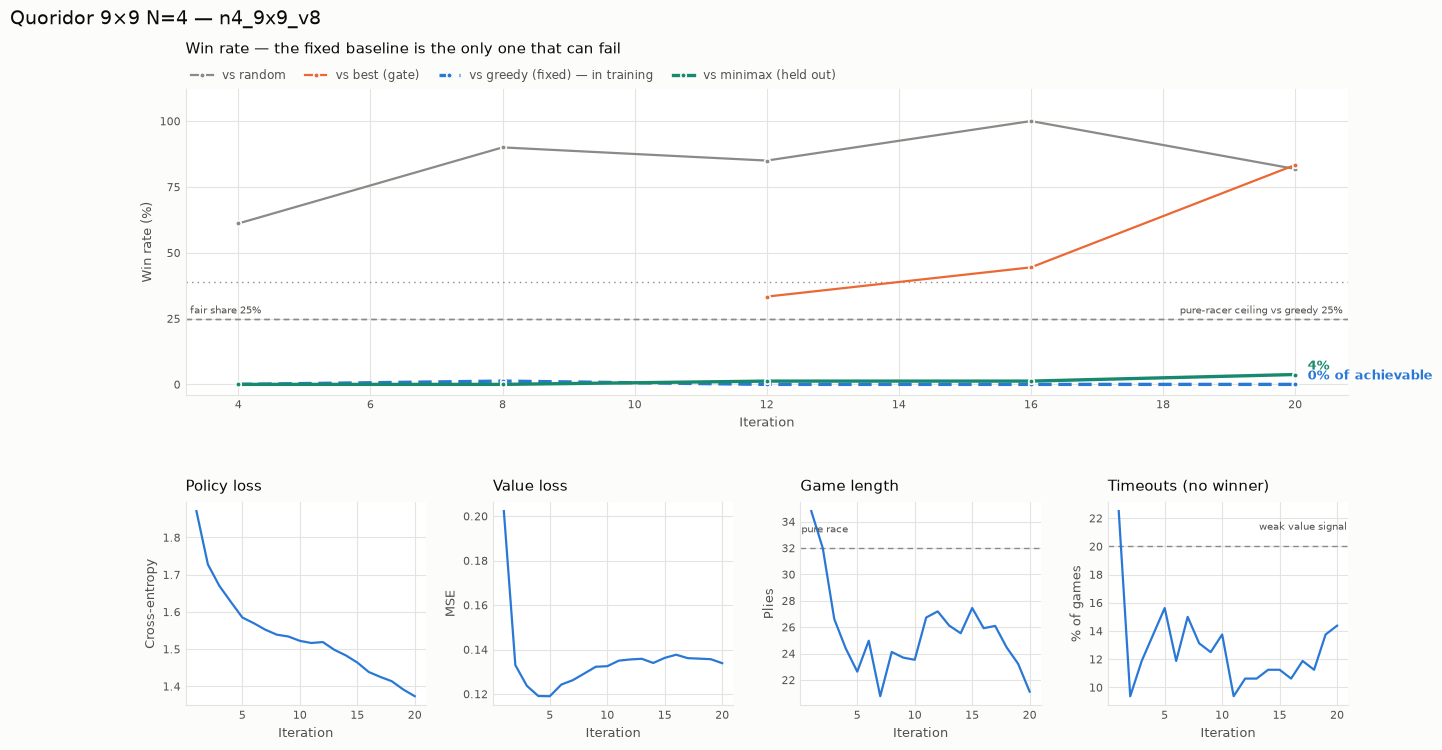

Iterations completed: 20
Policy loss: 1.3733   Value loss: 0.1339
vs random               81.8%  (iter 20)
vs best (gate)          83.3%  (iter 20)
vs greedy (fixed)        0.0%  (iter 20)   0% of achievable (ceiling 25%)
vs minimax (held out)    3.8%  (iter 20)
Accepted 0 of 5 evals (fair share 25%)


In [10]:
# 6.1 — Training curves
# Figure code is shared with the other variant's notebook and with
# scripts/plot_runs.py; run_settings reads this run's own frozen config, so all
# three draw the same fair-share, accept and pure-race references.
import matplotlib.pyplot as plt

from src.utils.history import load_meta, summary_lines
from src.utils.plots import plot_run

try:
    plot_run(RUN_DIR)
    plt.show()
    print("\n".join(summary_lines(load_meta(RUN_DIR)["history"], 1.0 / N)))
except (FileNotFoundError, ValueError) as exc:
    print(f"No figure yet — {exc}")


In [11]:
# 6.2 — Metrics table
from src.utils.history import eval_value

if metrics:
    print(f"{'Iter':>4} | {'Loss_P':>8} | {'Loss_V':>8} | {'WR_Random':>9} | "
          f"{'WR_Best':>7} | {'WR_Greedy':>9} | {'Decided':>7} | {'Accepted':>8}")
    print("-" * 84)
    for m in metrics:
        # eval_value returns None on skipped iterations — print a dash, never 0%.
        wr_r = eval_value(m, "win_vs_random")
        wr_b = eval_value(m, "win_vs_best")
        wr_g = eval_value(m, "win_vs_greedy")
        dec = m.get('decided_games')
        print(
            f"{m['iter']:4d} | "
            f"{m['loss_p']:8.4f} | "
            f"{m['loss_v']:8.4f} | "
            f"{f'{wr_r:8.1%}' if wr_r is not None else '       —'} | "
            f"{f'{wr_b:6.1%}' if wr_b is not None else '     —'} | "
            f"{f'{wr_g:8.1%}' if wr_g is not None else '       —'} | "
            f"{f'{dec:7d}' if dec is not None else '      —'} | "
            f"{'✓' if m.get('accepted') else ''}"
        )

NameError: name 'metrics' is not defined


Running: scripts/plot_training.py


✗ scripts/plot_training.py failed (exit 1)

  File "/tf/dl-quoridor/scripts/plot_training.py", line 246, in <module>
    plot_training_dashboard(metrics, output)
  File "/tf/dl-quoridor/scripts/plot_training.py", line 25, in plot_training_dashboard
    iters = [m["iteration"] for m in metrics]
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tf/dl-quoridor/scripts/plot_training.py", line 25, in <listcomp>
    iters = [m["iteration"] for m in metrics]
             ~^^^^^^^^^^^^^
TypeError: string indices must be integers, not 'str'


Running: scripts/plot_all_figures.py


✓ scripts/plot_all_figures.py completed
N=4: 70 iterations loaded
2p:  19 iterations loaded
Saved: runs/n4_5x5_v3/figures/n4_training_curves.png
Saved: runs/n4_5x5_v3/figures/n4_full_dashboard.png
Saved: runs/legacy_2p/figures/2p_training_dashboard.png
Saved: outputs/model_comparison.png
Saved: outputs/gamma_drift_ablation.png

N=4 figures   -> runs/n4_5x5_v3/figures/
2p figures    -> runs/legacy_2p/figures/
comparison    -> outputs/model_comparison.png
γ-drift       -> outputs/gamma_drift_ablation.png


📊 gamma_drift_ablation.png


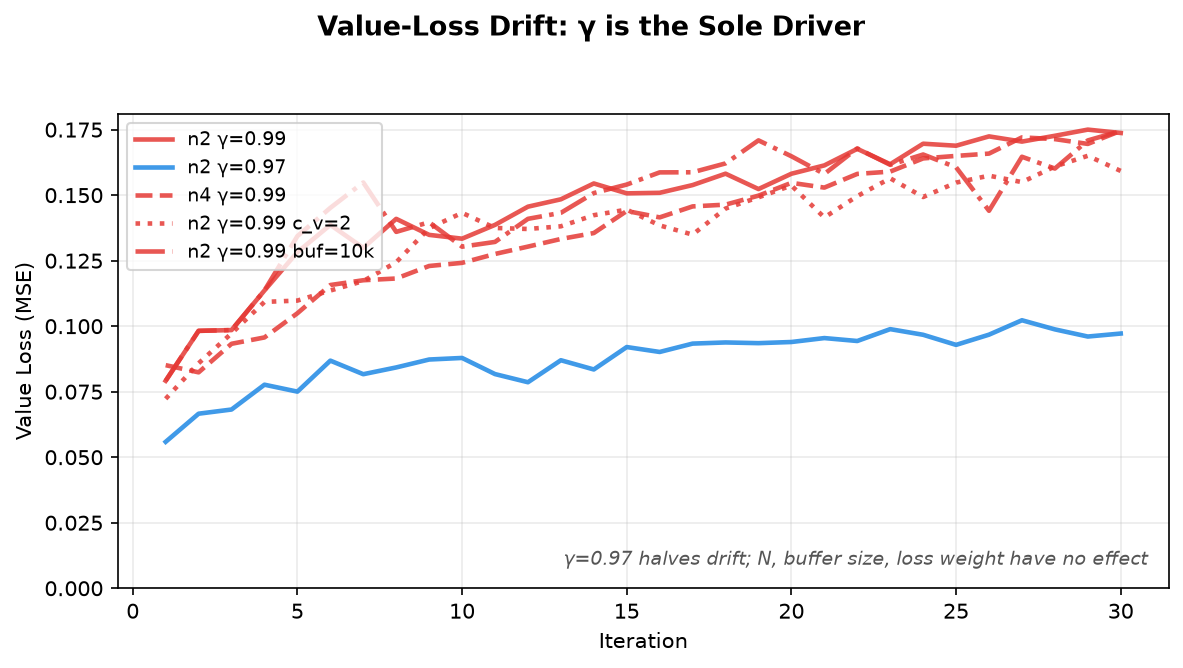


📊 model_comparison.png


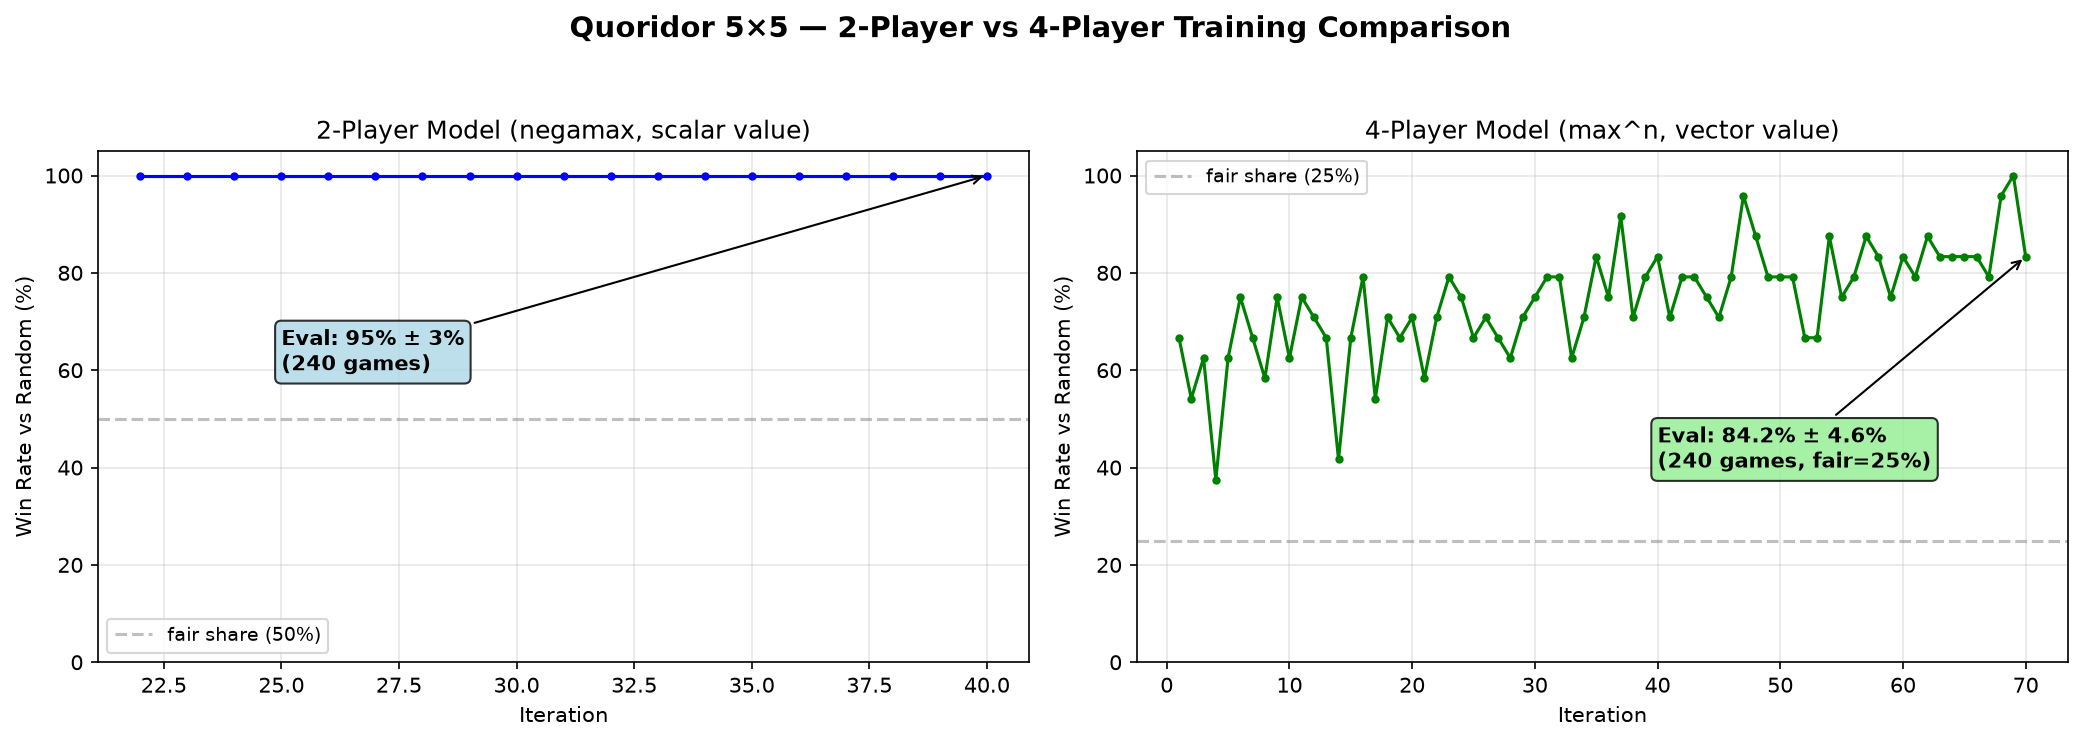

In [12]:
# 6.3 — Run all graph/plotting scripts
import subprocess, os

os.chdir(REPO_DIR)

scripts = [
    "scripts/plot_training.py",
    "scripts/plot_all_figures.py",
]

for script in scripts:
    if os.path.exists(script):
        print(f"\n{'='*60}")
        print(f"Running: {script}")
        print(f"{'='*60}")
        result = subprocess.run(
            ["python", script, RUN_DIR + "/meta.json"] if "plot_training" in script
            else ["python", script],
            capture_output=True, text=True,
            env={**os.environ, "PYTHONPATH": REPO_DIR}
        )
        if result.returncode == 0:
            print(f"✓ {script} completed")
            if result.stdout.strip():
                print(result.stdout[-500:])
        else:
            print(f"✗ {script} failed (exit {result.returncode})")
            print(result.stderr[-500:])
    else:
        print(f"⚠ {script} not found — skipping")

# Show generated figures
from IPython.display import Image, display
from pathlib import Path

fig_dirs = [
    Path(RUN_DIR) / "figures",
    Path(REPO_DIR) / "outputs",
]
for fig_dir in fig_dirs:
    if fig_dir.exists():
        for img in sorted(fig_dir.glob("*.png")):
            print(f"\n📊 {img.name}")
            display(Image(filename=str(img), width=900))

---
## 6.4 Final Evaluation at Full Sims (for the report)

Training used reduced sims (`eval_simulations`) for fast gating decisions. This
cell re-evaluates the final `best.pt` at the **full `num_simulations`** budget to
get the true strength numbers for the project book. Run once after training.

In [13]:
# 6.4 — Final evaluation at full sims (true strength for the report)
from src.env.quoridor_env_mp import QuoridorEnvMP
from src.model.network_mp import QuoridorModelMP
from src.mcts.training_mp import _mcts, TrainingConfigMP
from src.mcts.evaluator_mp import evaluate_against_random_mp, mcts_agent_mp
from src.utils.checkpoint import resolve_ship_checkpoint

FINAL_EVAL_GAMES = 100   # more games = tighter confidence interval

# Same resolution the export cell uses: best.pt when a candidate was ever
# accepted, else latest.pt — never the untrained champion.
eval_path, eval_label = resolve_ship_checkpoint(RUN_DIR)
if eval_path is None:
    print(f"Nothing to evaluate — {eval_label}")
else:
    print(f"Evaluating {eval_label}")
    eval_env = QuoridorEnvMP(board_size=BOARD, num_players=N, max_turns=MAX_TURNS,
                             max_walls_per_player=WALLS)
    final_model = QuoridorModelMP(
        board_size=BOARD, action_space_size=ACTION_SIZE,
        in_channels=IN_CHANNELS, num_channels=NUM_CHANNELS,
        num_res_blocks=NUM_RES_BLOCKS, num_players=N, device="auto",
    )
    final_model.load(eval_path)

    # Full-sim config (uses num_simulations, NOT eval_simulations)
    full_cfg = TrainingConfigMP(
        num_players=N, mcts_simulations=MCTS_SIMS,
        max_game_moves=MAX_MOVES,
        mcts_dirichlet_epsilon=cfg.get('mcts', {}).get('dirichlet_epsilon', 0.25),
        mcts_dirichlet_alpha=rc['dirichlet_alpha'],
        mcts_c_puct=rc['c_puct'],
    )
    agent = mcts_agent_mp(_mcts(final_model, eval_env, full_cfg), temperature=0.1)

    print(f"Running FULL {MCTS_SIMS} sims over {FINAL_EVAL_GAMES} games vs random...")
    res = evaluate_against_random_mp(eval_env, agent,
                                     num_games=FINAL_EVAL_GAMES, max_moves=MAX_MOVES)

    wr = res.candidate_win_rate
    # 95% binomial confidence interval over the games that actually finished
    import math
    n_dec = max(res.decided_games, 1)
    se = math.sqrt(wr * (1 - wr) / n_dec)
    ci = 1.96 * se
    fair = 1.0 / N
    print(f"\n=== FINAL STRENGTH (full {MCTS_SIMS} sims) ===")
    print(f"Checkpoint:    {eval_label}")
    print(f"Win vs random: {wr:.1%} ± {ci:.1%} (95% CI)  [fair share = {fair:.0%}]")
    print(f"Games: {FINAL_EVAL_GAMES} ({n_dec} decided) | {res.summary()}")

Evaluating latest.pt (iter 20) — no iteration was ever accepted, so best.pt is the untrained initialization
Running FULL 600 sims over 100 games vs random...



=== FINAL STRENGTH (full 600 sims) ===
Checkpoint:    latest.pt (iter 20) — no iteration was ever accepted, so best.pt is the untrained initialization
Win vs random: 87.7% ± 8.0% (95% CI)  [fair share = 25%]
Games: 100 (65 decided) | games=100 (decided 65) | candidate 57 (87.7% of decided, fair=25.0%) | opp 8 | draws 35 (35%) | by-seat[s0:6/25 s1:17/25 s2:18/25 s3:16/25]
